<a href="https://colab.research.google.com/github/DebStar17/Make-Moons/blob/main/Neural_Network_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Network

In [177]:
import random
import numpy as np

# ACTIVATION FUNCTIONS
def softmax(z):
    e_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return e_z / np.sum(e_z, axis=0, keepdims=True)

def sigmoid(z):
    # Caps the values between -250 and 250
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    """Derivative of the sigmoid function."""
    return sigmoid(z)*(1-sigmoid(z))

def relu(z):
    return np.maximum(0, z)

def relu_prime(z):
    return np.where(z > 0, 1, 0)

def compute_categorical_cross_entropy(output, y_true):
    # Clip values slightly to prevent log(0) -> NaN errors
    output = np.clip(output, 1e-15, 1.0 - 1e-15)
    m = y_true.shape[1]
    return -np.sum(y_true * np.log(output)) / m

# Actual Network Code
class Layer():
    def __init__(self, out_size, inp_size, activation, activation_prime):
        self.size = out_size
        self.bias = np.random.randn(out_size, 1)
        self.weight_mat = np.random.randn(out_size, inp_size) * np.sqrt(2.0 / inp_size)
        self.activation = activation
        self.activation_prime = activation_prime

    def give_input(self, input):
        self.input = input
        self.z = np.dot(self.weight_mat, self.input) + self.bias
        self.output = self.activation(self.z)
        return self.output

class Network():

    def __init__(self, sizes):
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.layers = [] # this includes output layer

        # CHANGE THE ACTIVATION FUNCTION HERE
        for i in range(1, len(sizes)):
            if i == len(sizes) - 1:
                f = softmax
                f_prime = lambda z: 1
            else:
                f = relu
                f_prime = relu_prime
            self.layers.append(Layer(sizes[i], sizes[i-1], f, f_prime))

    def feedforward(self, a):
        assert type(a) == np.ndarray, "Input must be a numpy array"

        for layer in self.layers:
            a = layer.give_input(a)
        return a

    def backprop(self, y, alpha):
        assert type(y) == np.ndarray, "Input must be a numpy array"
        m = y.shape[1]

        # --- Output Layer ---
        layer = self.layers[-1]
        delta = (layer.output - y) * layer.activation_prime(layer.z)

        # Divide by m to average the gradient across the batch
        layer.weight_mat -= alpha * (1/m) * np.dot(delta, layer.input.T)
        layer.bias -= alpha * (1/m) * np.sum(delta, axis=1, keepdims=True)

        # --- Hidden Layers ---
        for i in range(1, len(self.layers)):
            layer = self.layers[-1 - i]
            prev_layer = self.layers[-i]

            delta = np.dot(prev_layer.weight_mat.T, delta) * layer.activation_prime(layer.z)
            layer.weight_mat -= alpha * (1/m) * np.dot(delta, layer.input.T)
            layer.bias -= alpha * (1/m) * np.sum(delta, axis=1, keepdims=True)

    def train(self, X, y, epochs, alpha, batch_size=32):
        self.losses = []
        assert type(X) == np.ndarray, "Input must be a numpy array"
        assert type(y) == np.ndarray, "Output must be a numpy array"
        num_samples = X.shape[0]  # Row count = total samples (800)

        for epoch in range(epochs):
            alpha *= 1
            # 1. Shuffle row indices
            permutation = np.random.permutation(num_samples)
            X_shuffled = X[permutation]
            y_shuffled = y[permutation]

            # 2. Loop through in steps of batch_size
            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i : i + batch_size].T
                y_batch = y_shuffled[i : i + batch_size].T

                # 4. Pass the batch through
                output = self.feedforward(X_batch)
                self.backprop(y_batch, alpha)

            full_output = self.feedforward(X.T)
            y_full_reshaped = y.T

            # Compute total MSE Loss for the entire dataset
            epoch_loss = compute_categorical_cross_entropy(full_output, y_full_reshaped)
            self.losses.append(epoch_loss)

#### Data

In [178]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist  # Fast distance calculation

# 1. Generate the standard 2-class moons
X_moons, y_moons = make_moons(n_samples=1000, noise=0.2, random_state=42)

# 2. Define the spatial limits based on your dataset bounds
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5

# 3. Generate random candidate points across the entire empty space box
# We generate extra candidates because some will be filtered out
X_candidates = np.random.uniform([x_min, y_min], [x_max, y_max], size=(1000, 2))

# 4. Filter out candidate points that land too close to the actual moon data
# cdist calculates the distance from every candidate to every moon point
distances = cdist(X_candidates, X_moons)
min_distances = np.min(distances, axis=1)

# Keep only the points that are at least 0.25 units away from any real data point
X_blank = X_candidates[min_distances > 0.05]
y_blank = np.ones(X_blank.shape[0]) * 2  # Label "blank" space as Class 2

# 5. Merge the original moons data with your new "blank" background data
X = np.vstack([X_moons, X_blank])
y_labels = np.concatenate([y_moons, y_blank]).astype(int)
# np.eye(3) creates a 3x3 identity matrix. Indexing it with y_labels
# maps 0 -> [1,0,0], 1 -> [0,1,0], and 2 -> [0,0,1]
y = np.eye(3)[y_labels]

# 6. Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

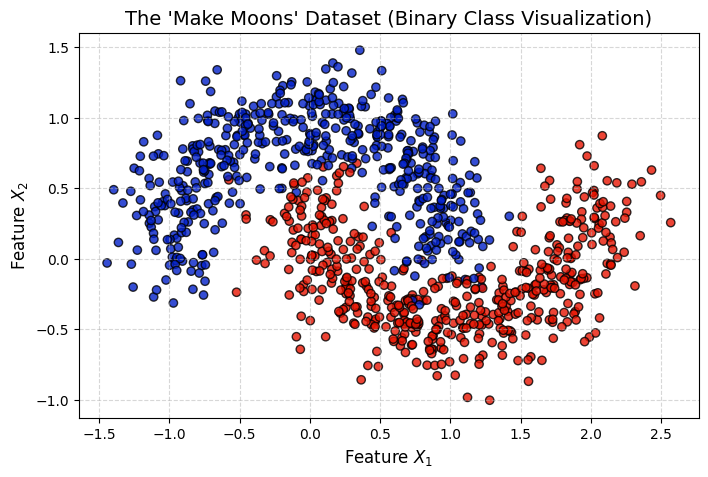

In [179]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. Create your custom colormap: index 0 = dark blue, index 1 = dark red
custom_cmap = ListedColormap(['#0220c9', '#e81502'])

# 2. Create a mask picking only data points belonging to class 0 or 1
visible_mask = (y_labels == 0) | (y_labels == 1)

plt.figure(figsize=(8, 5))

# 3. Filter X and y_labels using the mask so class 2 is completely hidden
plt.scatter(
    X[visible_mask, 0],
    X[visible_mask, 1],
    c=y_labels[visible_mask],  # Passes 0s and 1s to match the custom_cmap colors
    cmap=custom_cmap,
    edgecolors='k',
    alpha=0.8
)

# Adding labels and styling
plt.title("The 'Make Moons' Dataset (Binary Class Visualization)", fontsize=14)
plt.xlabel("Feature $X_1$", fontsize=12)
plt.ylabel("Feature $X_2$", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()

In [180]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def plot_decision_boundary(net, X, y):
    # 1. Define the limits of the plot based on your dataset bounds
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # 2. Create a dense grid of points (spacing of 0.01)
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01)
    )

    # 3. Flatten the grid arrays and stack them into a (2, N) matrix
    grid_points = np.vstack([xx.ravel(), yy.ravel()])

    # 4. Get the network's predictions for the entire grid
    # probs shape: (3, N) -> rows are Class 0, Class 1, Class 2
    probs = net.feedforward(grid_points)

    # --- NEW: Get the dominant class for background shading ---
    # np.argmax along axis=0 gives an array of shape (N,) containing 0, 1, or 2
    grid_classes = np.argmax(probs, axis=0)
    grid_classes = grid_classes.reshape(xx.shape)

    plt.figure(figsize=(8, 5))

    # 5. Define discrete background colormaps matching your classes
    # Light versions for the background regions: light blue, light red, light gray (blank)
    bg_cmap = ListedColormap(["#abcdef", "#ffcccc", "#f0f0f0"])
    # Bold colors for the actual data scatter points: dark blue, dark red
    scatter_cmap = ListedColormap(["#0220c9", "#e81502"])

    # 6. Plot the filled background regions representing class territories
    plt.contourf(xx, yy, grid_classes, levels=[-0.5, 0.5, 1.5, 2.5], cmap=bg_cmap)

    # 7. Draw sharp contour lines to highlight where the data boundaries live
    # We slice probs to look specifically at Class 0 and Class 1 probability fields
    probs_class0 = probs[0, :].reshape(xx.shape)
    probs_class1 = probs[1, :].reshape(xx.shape)

    # This draws contour arcs tightly hugging your data clusters
    plt.contour(
        xx, yy, probs_class0, levels=[0.50], colors="black", linestyles="--", linewidths=2, zorder = 3
    )
    plt.contour(
        xx, yy, probs_class1, levels=[0.50], colors="black", linestyles="--", linewidths=2, zorder = 3
    )

    # 8. Scatter plot the actual training data points on top (hiding class 2)
    # Convert one-hot y targets back to 1D labels for plotting filtering
    y_labels = np.argmax(y, axis=1)
    visible_mask = (y_labels == 0) | (y_labels == 1)

    plt.scatter(
        X[visible_mask, 0],
        X[visible_mask, 1],
        c=y_labels[visible_mask],
        cmap=scatter_cmap,
        edgecolors="k",
        s=40,
        zorder=2,
    )

    plt.title(
        "3-Class Multi-Class Decision Boundary & Territories", fontsize=14
    )
    plt.xlabel("Feature $X_1$")
    plt.ylabel("Feature $X_2$")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

#### Start

In [188]:
net = Network([2,30,30,3])
epochs=500
alpha=0.003
batch_size=32
net.train(X_train, y_train, epochs, alpha, batch_size)

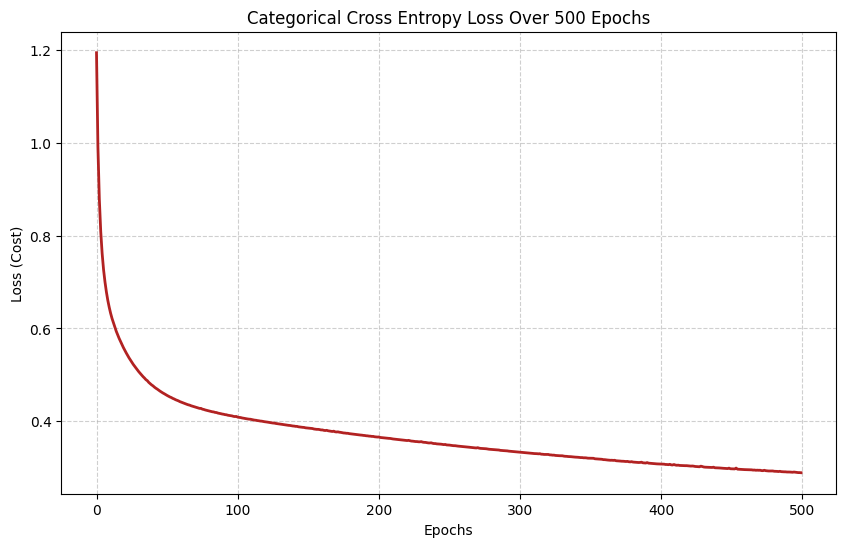

In [189]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(net.losses, color='firebrick', linewidth=2)
plt.title(f"Categorical Cross Entropy Loss Over {epochs} Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (Cost)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Test Accuracy: 89.92%


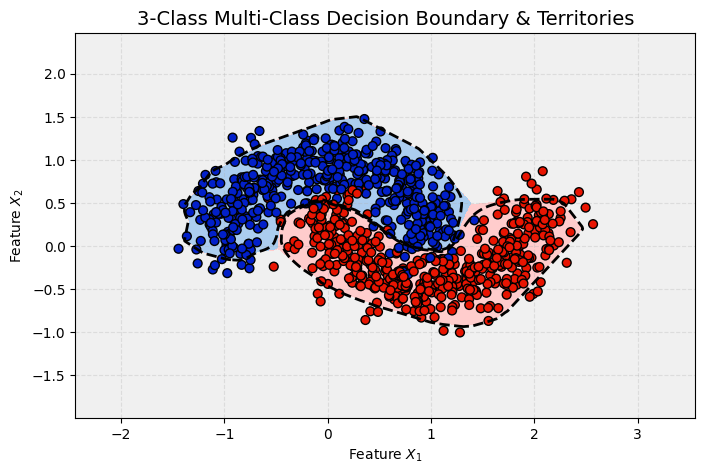

In [190]:
from sklearn.metrics import accuracy_score

probs = net.feedforward(X_test.T)  # remember to pass test data transposed
preds = np.argmax(probs, axis=0)

y_test_labels = np.argmax(y_test.T, axis=0)
accuracy = accuracy_score(y_test_labels, preds)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# 4. Plot it!
plot_decision_boundary(net, X, y)